<a href="https://colab.research.google.com/github/ASAND5/Portfolio/blob/main/K_mean_256_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade Pillow
!pip install image

In [2]:
!pip install --upgrade imageio scikit-image

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as image
%matplotlib inline
plt.style.use("ggplot")

from skimage import io
from skimage.io import imread, imshow
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.datasets import load_sample_image
import seaborn as sns; sns.set()

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

(1536, 1024, 3)
4718592


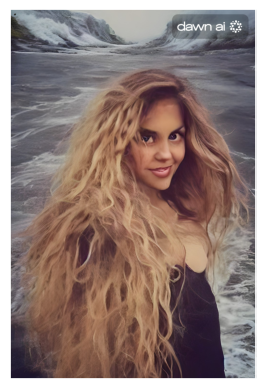

In [4]:
her = imread('/content/drive/MyDrive/ai/1664250962729.jpg')
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(her);
print(her.shape)
print(her.size)

In [6]:
mine = her / 255.0 # use 0...1 scale
mine = mine.reshape(1536 * 1024, 3)
mine.shape

(1572864, 3)

In [7]:
def plot_pixels(mine, title, colors=None, N=10000):
    if colors is None:
        colors = mine

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(mine.shape[0])[:N]
    colors = colors[i]
    R, G, B = mine[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);


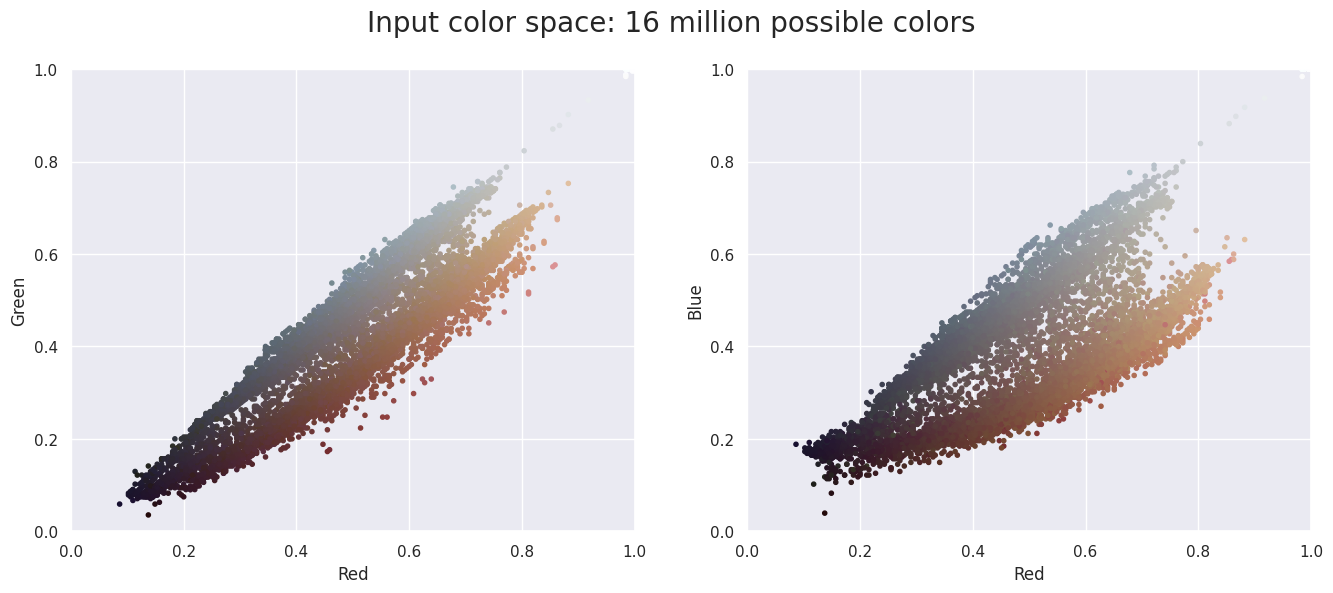

In [11]:
plot_pixels(mine, title='Input color space: 16 million possible colors')

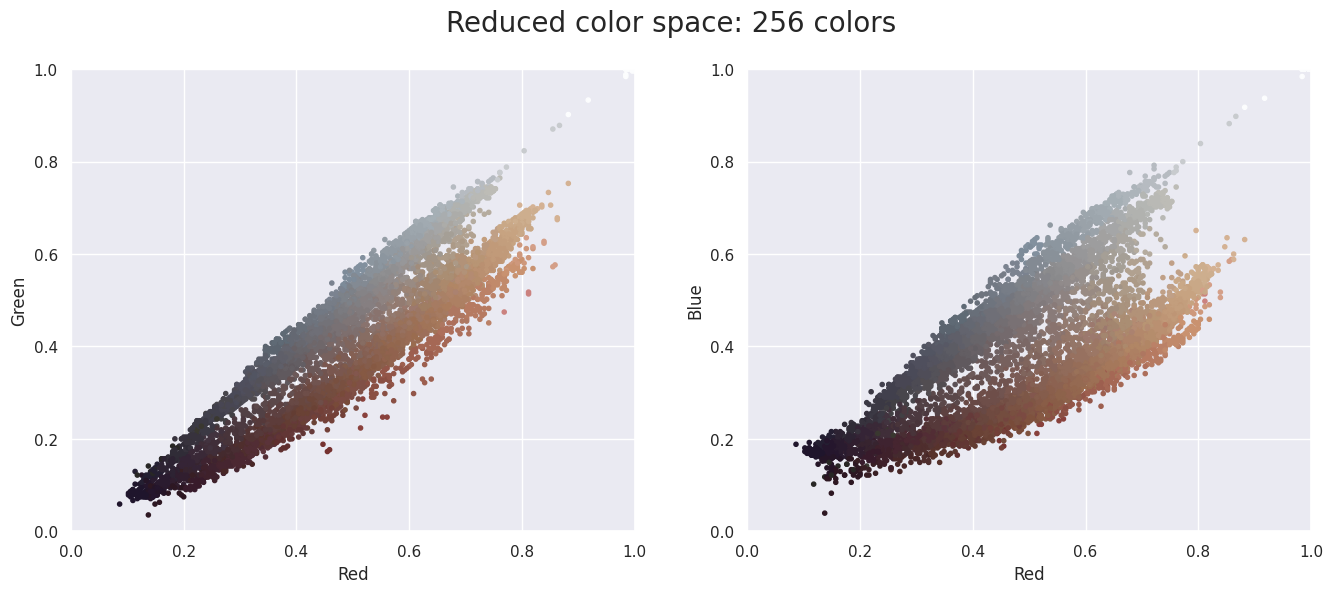

In [12]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(256)
kmeans.fit(mine)
new_colors = kmeans.cluster_centers_[kmeans.predict(mine)]

plot_pixels(mine, colors=new_colors,
            title="Reduced color space: 256 colors")

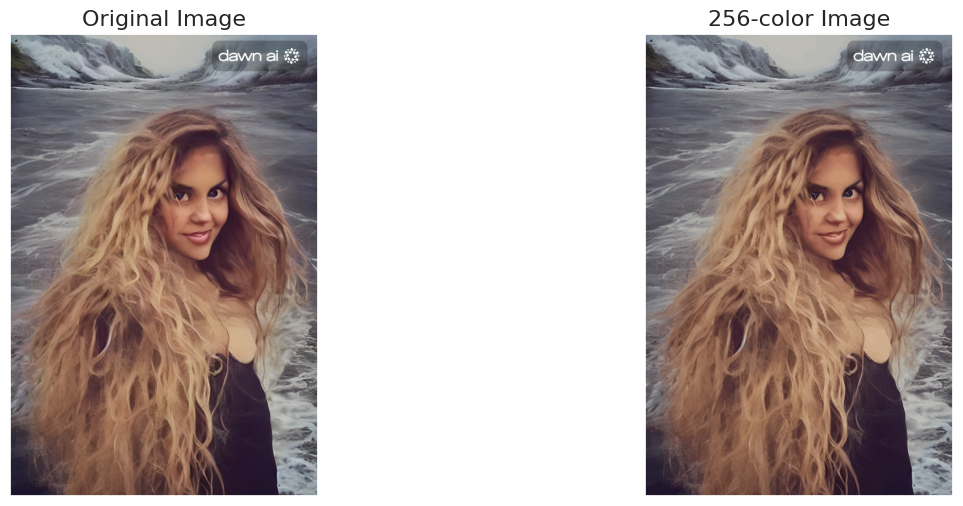

In [13]:
her_recolored = new_colors.reshape(her.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(her)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(her_recolored)
ax[1].set_title('256-color Image', size=16);

# store to file
plt.savefig("her_kmean.png", dpi=729)